In [1]:
import os
import pandas as pd
import numpy as np
from dataclasses import dataclass, field

In [2]:
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
"""def preprocess_trackman(df):
    preprocessed_trackman = df.copy()

    preprocessed_trackman = preprocessed_trackman.drop_duplicates(subset=preprocessed_trackman.columns.drop("trackman_id"),keep="first").reset_index(drop=True)
   
    preprocessed_trackman["game_date_raw"] = preprocessed_trackman["game_date"].astype("string")
    preprocessed_trackman["game_date"] = pd.to_datetime(preprocessed_trackman["game_date"], format="mixed", errors="coerce")

    def normalize_pitch_type(series):
        normalized = (series.astype("string").str.strip().str.lower().str.replace(r"[\s_-]+", "", regex=True))
        invalid_values = [
        "undefined",
        "undefined#",
        "undefind"
        ]

        return normalized.mask(normalized.isin(invalid_values),pd.NA)

    preprocessed_trackman["tagged_pitch_type_clean"] = normalize_pitch_type(preprocessed_trackman["tagged_pitch_type"])
    preprocessed_trackman["auto_pitch_type_clean"] = normalize_pitch_type(preprocessed_trackman["auto_pitch_type"])
    preprocessed_trackman["pitch_type_clean"] = (preprocessed_trackman["tagged_pitch_type_clean"].fillna(preprocessed_trackman["auto_pitch_type_clean"]).fillna("unknown"))
    preprocessed_trackman.drop(columns = ["tagged_pitch_type",'auto_pitch_type'], inplace=True)

    preprocessed_trackman["invalid_balls"] = (~preprocessed_trackman["balls_before"].between(0, 3)).astype("int8")
    preprocessed_trackman["invalid_strikes"] = (~preprocessed_trackman["strikes_before"].between(0, 2)).astype("int8")
    preprocessed_trackman["invalid_outs"] = (~preprocessed_trackman["outs_before"].between(0, 2)).astype("int8")
    preprocessed_trackman["invalid_inning"] = (preprocessed_trackman["inning"].lt(1)).astype("int8")
    preprocessed_trackman["invalid_pitch_of_pa"] = (preprocessed_trackman["pitch_of_pa"].lt(1)).astype("int8")
    preprocessed_trackman["invalid_game_state"] = (
        preprocessed_trackman[
            [
                "invalid_balls",
                "invalid_strikes",
                "invalid_outs",
                "invalid_inning",
                "invalid_pitch_of_pa",
            ]
        ]
        .any(axis=1)
        .astype("int8")
    )

    measure_cols = [
        "rel_speed",
        "spin_rate",
        "induced_vert_break",
        "horz_break",
        "extension",
        "rel_height",
        "rel_side",
        "zone_speed",
    ]

    preprocessed_trackman["measure_missing_count"] = (preprocessed_trackman[measure_cols].isna().sum(axis=1).astype("int8"))
    preprocessed_trackman["any_measure_missing"] = (preprocessed_trackman["measure_missing_count"].gt(0).astype("int8"))
    preprocessed_trackman["all_measure_missing"] = (preprocessed_trackman["measure_missing_count"].eq(len(measure_cols)).astype("int8"))

    preprocessed_trackman["speed_loss"] = (preprocessed_trackman["rel_speed"] - preprocessed_trackman["zone_speed"]).astype("float32")
    preprocessed_trackman["absolute_horz_break"] = (preprocessed_trackman["horz_break"].abs()).astype("float32")
    preprocessed_trackman["absolute_vert_break"] = (preprocessed_trackman["induced_vert_break"].abs()).astype("float32")

    categorical_cols = [
        "trackman_game_id",
        "pitcher_trackman_id",
        "batter_trackman_id",
        "top_bottom",
        "pitcher_hand",
        "batter_hand",
        "pitcher_team",
        "batter_team",
        "tagged_pitch_type_clean",
        "auto_pitch_type_clean",
        "pitch_type_clean"
    ]

    for col in categorical_cols:
        preprocessed_trackman[col] = (preprocessed_trackman[col].astype("string").fillna("__MISSING__").astype("category"))

    return preprocessed_trackman"""

In [3]:
@dataclass
class Config:
    seed : int =  42
    data_dir : str = './data'
    target : str = 'control_success'
    id : str = 'row_id'

    id_cols : list[str] = field(default_factory= lambda: [
        'row_id',
        'pitcher_id',
        'batter_id'
        ])
    
    cat_cols : list[str] = field(default_factory= lambda: [
        "top_bottom",
        "game_type",
        "base_state",
        "game_dayofweek",
        "pitcher_hand",
        "batter_hand",
        "pitcher_team_id",
        "batter_team_id"
        ])

    drop_cols : list[str] = field(default_factory= lambda: [
        "run_top_before",
        "run_bot_before",
        "run_total_before",
        "score_diff_home",
        "asof_pitcher_pitchmix_n",
        "base_state",
        "home_win_expectancy",
        "away_win_expectancy"
        ])
    
    recent_cols : list[str] = field(default_factory= lambda: [
        "asof_pitcher_prev1_game_success_rate",
        "asof_pitcher_prev3_game_success_rate",
        "asof_pitcher_prev5_game_success_rate",
        "asof_pitcher_prev1_game_middle_rate",
        "asof_pitcher_prev3_game_middle_rate",
        "asof_pitcher_prev5_game_middle_rate",
    ])

In [21]:
full_train = pd.read_csv(os.path.join(Config().data_dir, 'train.csv'))
train = full_train.loc[full_train.season < 2024].copy()
val = full_train.loc[full_train.season == 2024].copy()

print("full_train",full_train.shape)
print("train",train.shape)
print("validation",val.shape)

full_train (1475092, 49)
train (1221585, 49)
validation (253507, 49)


In [5]:
results = []

**Baseline**

In [4]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer

train: (1221585, 47)
val: (253507, 47)
학습 완료 :: 28.5s
Brier: 0.248769 | 기준선 r(1-r): 0.249807
Validation Score: 415.57


<BarContainer object of 47 artists>

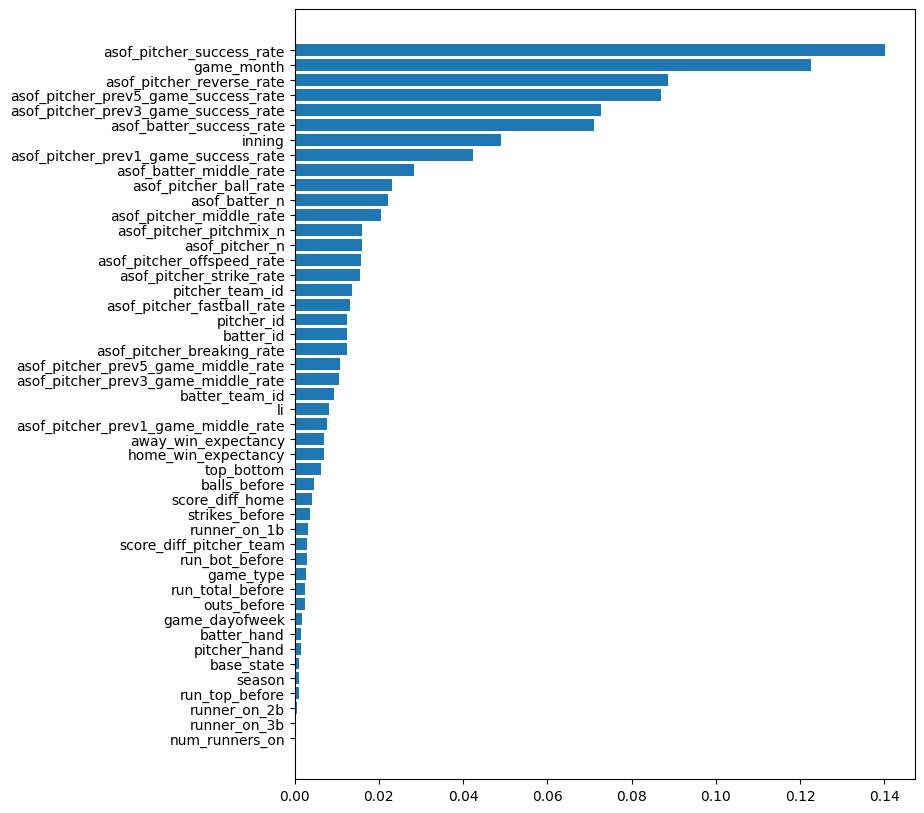

In [7]:
CAT_COLS = ["top_bottom", "game_type", "base_state"]
config = Config(cat_cols = CAT_COLS)
target = config.target
id = config.id_cols[0]
features = [col for col in train.columns if col not in [id, target]]
num_cols = [col for col in features if col not in config.cat_cols]

preprocessor = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value",
                           unknown_value=-1), config.cat_cols),
    ("num", SimpleImputer(strategy="median"), num_cols),
])

y_train, y_val = train.loc[:,target], val.loc[:,target]
X_train, X_val = train.loc[:,features], val.loc[:,features]
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print('train:', X_train_processed.shape)
print('val:', X_val_processed.shape)

params = {
    'n_estimators':100,
    'max_depth':10,
    'min_samples_leaf':200,
    'n_jobs':-1,
    'random_state': config.seed
}

model = RandomForestClassifier(**params)

t = time.time()
model.fit(X_train_processed,y_train)
spent = time.time() - t
print(f"학습 완료 :: {spent:.1f}s")

val_pred = model.predict_proba(X_val_processed)[:, 1]

r = y_val.mean()
brier = ((val_pred - y_val) ** 2).mean()
baseline_brier = r * (1 - r)
score = max(0, 100000 * (1 - brier / baseline_brier))

print(f"Brier: {brier:.6f} | 기준선 r(1-r): {baseline_brier:.6f}")
print(f"Validation Score: {score:.2f}")

importance_df = pd.DataFrame({'feature': X_train.columns,
                              'importance': model.feature_importances_
                              }).sort_values('importance')

plt.figure(figsize=(8, 10))
plt.barh(importance_df['feature'],importance_df['importance'])

In [8]:
name = "baseline"
results.append({
    'name': name,
    'validation':round(score,2),
    'time': round(spent,1),
    'model': str(model).split('(')[0],
    'parmeters': params,
    'importance_df': importance_df
})

print(pd.DataFrame(results))

       name  validation  time                   model  \
0  baseline      415.57  28.5  RandomForestClassifier   

                                           parmeters  \
0  {'n_estimators': 100, 'max_depth': 10, 'min_sa...   

                                       importance_df  
0                                   feature  impo...  


delete pitcher_id & batter_id

train: (1221585, 45)
val: (253507, 45)
학습 완료 :: 28.2s
Brier: 0.248737 | 기준선 r(1-r): 0.249807
Validation Score: 428.36


<BarContainer object of 45 artists>

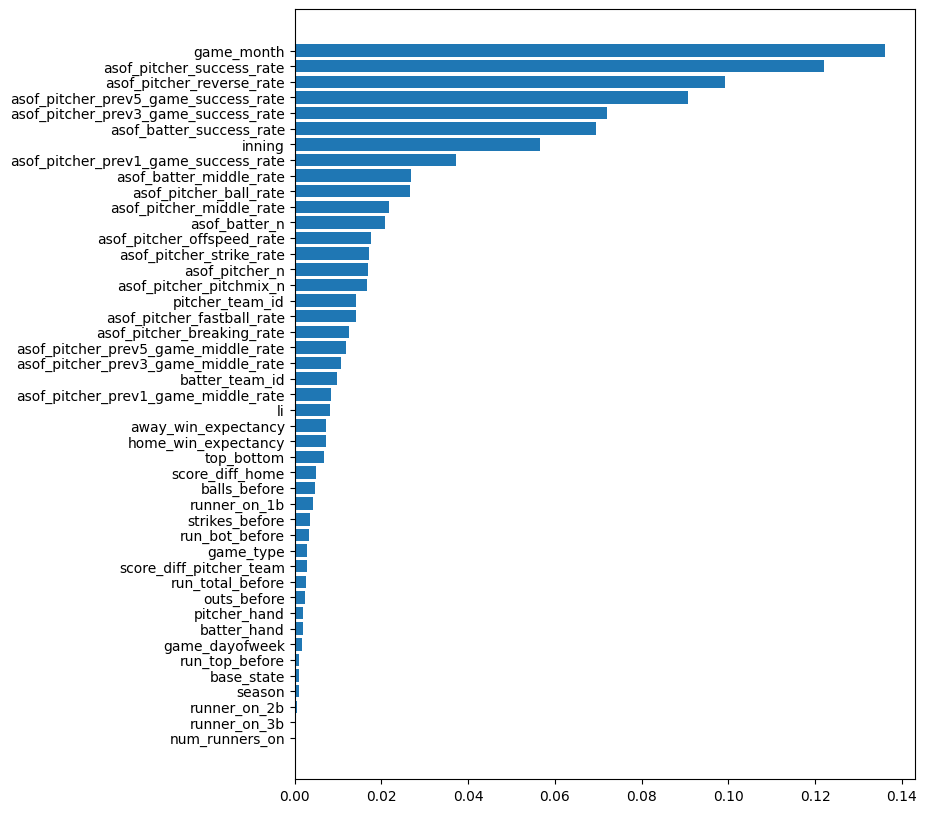

In [9]:
CAT_COLS = ["top_bottom", "game_type", "base_state"]
config = Config(cat_cols = CAT_COLS)
target = config.target
features = [col for col in train.columns if col not in [target] + config.id_cols]
num_cols = [col for col in features if col not in config.cat_cols]

preprocessor = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value",
                           unknown_value=-1), config.cat_cols),
    ("num", SimpleImputer(strategy="median"), num_cols),
])

y_train, y_val = train.loc[:,target], val.loc[:,target]
X_train, X_val = train.loc[:,features], val.loc[:,features]
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print('train:', X_train_processed.shape)
print('val:', X_val_processed.shape)

params = {
    'n_estimators':100,
    'max_depth':10,
    'min_samples_leaf':200,
    'n_jobs':-1,
    'random_state': config.seed
}

model = RandomForestClassifier(**params)

t = time.time()
model.fit(X_train_processed,y_train)
spent = time.time() - t
print(f"학습 완료 :: {spent:.1f}s")

val_pred = model.predict_proba(X_val_processed)[:, 1]

r = y_val.mean()
brier = ((val_pred - y_val) ** 2).mean()
baseline_brier = r * (1 - r)
score = max(0, 100000 * (1 - brier / baseline_brier))

print(f"Brier: {brier:.6f} | 기준선 r(1-r): {baseline_brier:.6f}")
print(f"Validation Score: {score:.2f}")

importance_df = pd.DataFrame({'feature': X_train.columns,
                              'importance': model.feature_importances_
                              }).sort_values('importance')

plt.figure(figsize=(8, 10))
plt.barh(importance_df['feature'],importance_df['importance'])

In [10]:
name = "delete_ids"
results.append({
    'name': name,
    'validation':round(score,2),
    'time': round(spent,1),
    'model': str(model).split('(')[0],
    'parmeters': params,
    'importance_df': importance_df
})

pd.DataFrame(results)

         name  validation  time                   model  \
0    baseline      415.57  28.5  RandomForestClassifier   
1  delete_ids      428.36  28.2  RandomForestClassifier   

                                           parmeters  \
0  {'n_estimators': 100, 'max_depth': 10, 'min_sa...   
1  {'n_estimators': 100, 'max_depth': 10, 'min_sa...   

                                       importance_df  
0                                   feature  impo...  
1                                   feature  impo...  


feature engineering

In [5]:
def preprocess_data(df, config=None,state=None,fit=False):
    processed_df = df.copy()
    config = config

    categorical_cols = config.cat_cols

    is_top = processed_df["top_bottom"].eq("T")
    processed_df["pitcher_is_home"] = is_top.astype("int8")
    processed_df["pitcher_team_runs"] = np.where(is_top, processed_df["run_bot_before"], processed_df["run_top_before"]).astype("int16")
    processed_df["opponent_team_runs"] = np.where(is_top, processed_df["run_top_before"], processed_df["run_bot_before"]).astype("int16")
    processed_df["pitcher_team_win_expectancy"] = np.where(is_top, processed_df["home_win_expectancy"], processed_df["away_win_expectancy"])
    processed_df["pitcher_cold_start"] = (processed_df["asof_pitcher_n"].eq(0) | processed_df["asof_pitcher_success_rate"].isna()).astype("int8")
    processed_df["batter_cold_start"] = (processed_df["asof_batter_n"].eq(0) | processed_df["asof_batter_success_rate"].isna()).astype("int8")

    recent_cols = config.recent_cols

    processed_df["pitcher_recent_missing"] = (processed_df[recent_cols].isna().any(axis=1).astype("int8"))

    processed_df["is_late_inning"] = (processed_df["inning"].ge(7).astype("int8"))
    processed_df["is_close_game"] = (processed_df["score_diff_pitcher_team"].abs().le(1).astype("int8"))
    processed_df["has_risp"] = (processed_df["runner_on_2b"].eq(1) | processed_df["runner_on_3b"].eq(1)).astype("int8")
    processed_df["count_pressure"] = (processed_df["balls_before"]+ processed_df["strikes_before"]).astype("int8")
    processed_df["same_hand_matchup"] = (processed_df["pitcher_hand"] == processed_df["batter_hand"]).astype("int8")

    drop_cols = config.drop_cols

    if fit:
        state = {
            "categories": {},
            "drop_cols": [],
        }

        state["drop_cols"].extend(drop_cols)

    elif state is None:
        raise ValueError("validation/test 변환 시 train에서 생성한 state를 전달해야 합니다.")

    processed_df = processed_df.drop(
        columns=state["drop_cols"],
        errors="ignore",
    )

    existing_cat_cols = [col for col in categorical_cols if col in processed_df.columns]

    for col in existing_cat_cols:
        values = processed_df[col].astype("string")

        if fit:
            categories = (values.dropna().drop_duplicates().tolist())
            state["categories"][col] = categories

        categories = state["categories"][col]

        processed_df[col] = pd.Categorical(values,categories=categories)

    state["categorical_cols"] = existing_cat_cols

    return processed_df, state

In [12]:
config = Config()
train,state = preprocess_data(train,config=config,fit=True)
val,_ = preprocess_data(val,config=config,state=state,fit=False)

train: (1221585, 49)
val: (253507, 49)
학습 완료 :: 30.4s
Brier: 0.248632 | 기준선 r(1-r): 0.249807
Validation Score: 470.32


<BarContainer object of 49 artists>

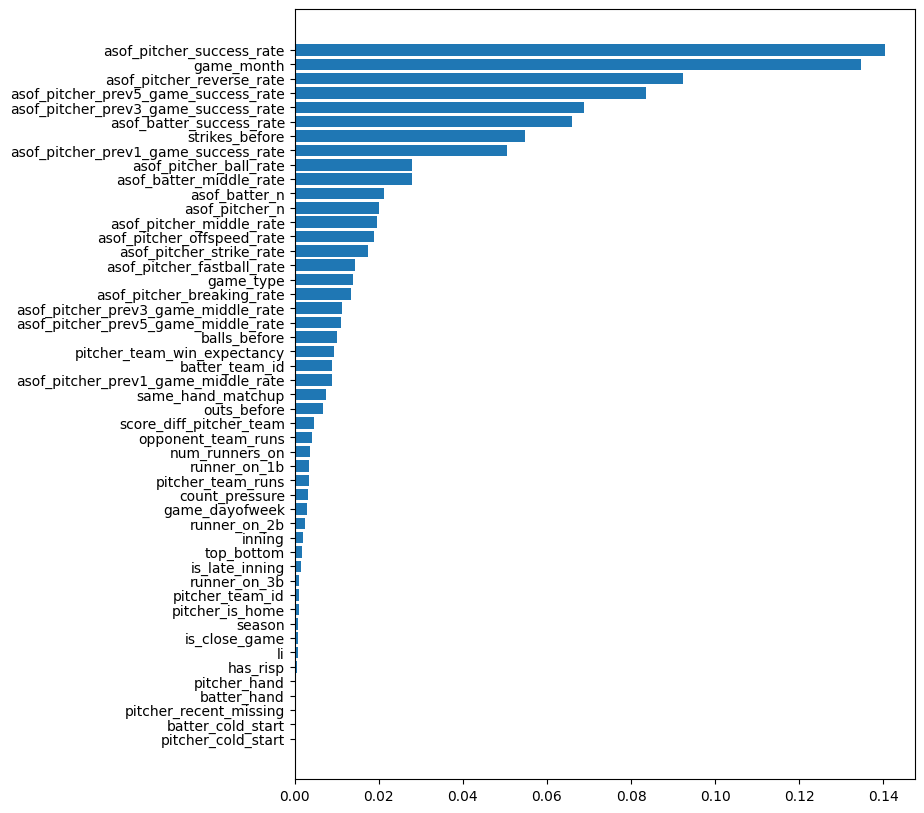

In [14]:
target = config.target
features = [col for col in train.columns if col not in [target] + config.id_cols]
cat_cols = state['categorical_cols']
num_cols = [col for col in features if col not in cat_cols]

preprocessor = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value",
                           unknown_value=-1), cat_cols),
    ("num", SimpleImputer(strategy="median"), num_cols),
])

y_train, y_val = train.loc[:,target], val.loc[:,target]
X_train, X_val = train.loc[:,features], val.loc[:,features]
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print('train:', X_train_processed.shape)
print('val:', X_val_processed.shape)

params = {
    'n_estimators':100,
    'max_depth':10,
    'min_samples_leaf':200,
    'n_jobs':-1,
    'random_state': config.seed
}

model = RandomForestClassifier(**params)

t = time.time()
model.fit(X_train_processed,y_train)
spent = time.time() - t
print(f"학습 완료 :: {spent:.1f}s")

val_pred = model.predict_proba(X_val_processed)[:, 1]

r = y_val.mean()
brier = ((val_pred - y_val) ** 2).mean()
baseline_brier = r * (1 - r)
score = max(0, 100000 * (1 - brier / baseline_brier))

print(f"Brier: {brier:.6f} | 기준선 r(1-r): {baseline_brier:.6f}")
print(f"Validation Score: {score:.2f}")

importance_df = pd.DataFrame({'feature': X_train.columns,
                              'importance': model.feature_importances_
                              }).sort_values('importance')

plt.figure(figsize=(8, 10))
plt.barh(importance_df['feature'],importance_df['importance'])

In [15]:
name = "feature_engineering"
results.append({
    'name': name,
    'validation':round(score,2),
    'time': round(spent,1),
    'model': str(model).split('(')[0],
    'parmeters': params,
    'importance_df': importance_df
})

pd.DataFrame(results)

,name,validation,time,model,parmeters,importance_df
0,baseline,415.57,28.5,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
1,delete_ids,428.36,28.2,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
2,feature_engineering,470.32,30.4,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...


**catboost & lightgbm**

In [16]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [57]:
def brier_skill_score(y_true,y_pred):
    r = y_true.mean()
    brier = ((y_pred - y_true) ** 2).mean()
    baseline_brier = r * (1 - r)
    score = max(0, 100000 * (1 - brier / baseline_brier))

    print(f"Brier: {brier:.6f} | 기준선 r(1-r): {baseline_brier:.6f}")
    print(f"Validation Score: {score:.2f}")

    return score, brier, baseline_brier

def return_importance_df():
    feature_names = (preprocessor.get_feature_names_out())
    importance_df = pd.DataFrame({'feature': feature_names,
                              'importance': model.feature_importances_
                              }).sort_values('importance')

    importance_df["feature"] = (
        importance_df["feature"]
        .str.replace("cat__", "", regex=False)
        .str.replace("num__", "", regex=False)
    )

    return importance_df.sort_values(
        "importance",
        ascending=False,
    )

def append_results(name):
    results.append({
    'name': name,
    'validation':round(score,2),
    'time': round(spent,1),
    'model': str(model).split('(')[0],
    'parmeters': params,
    'importance_df': importance_df
    })

    return pd.DataFrame(results)

def show_results():
    return pd.DataFrame(results)

baseline

train: (1221585, 47)
val: (253507, 47)
[LightGBM] [Info] Number of positive: 649372, number of negative: 572213
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.078396 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6371
[LightGBM] [Info] Number of data points in the train set: 1221585, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.531582 -> initscore=0.126494
[LightGBM] [Info] Start training from score 0.126494
학습 완료 :: 3.7s
Brier: 0.248286 | 기준선 r(1-r): 0.249807
Validation Score: 608.94


c:\Users\kaich\Desktop\open\aimers\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,name,validation,time,model,parmeters,importance_df
0,baseline,415.57,28.5,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
1,delete_ids,428.36,28.2,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
2,feature_engineering,470.32,30.4,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
3,baseline_lightgbm,608.94,3.7,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...


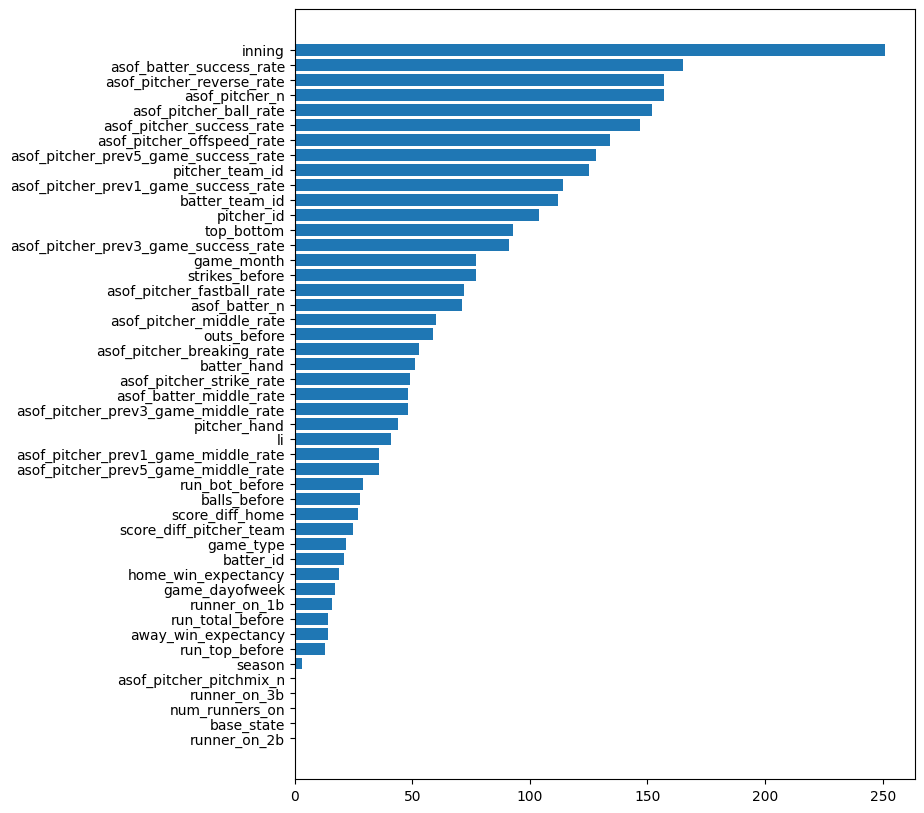

In [22]:
CAT_COLS = ["top_bottom", "game_type", "base_state"]
config = Config(cat_cols = CAT_COLS)
target = config.target
id = config.id_cols[0]
features = [col for col in train.columns if col not in [id, target]]
num_cols = [col for col in features if col not in config.cat_cols]

preprocessor = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value",
                           unknown_value=-1), config.cat_cols),
    ("num", SimpleImputer(strategy="median"), num_cols),
])

y_train, y_val = train.loc[:,target], val.loc[:,target]
X_train, X_val = train.loc[:,features], val.loc[:,features]
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print('train:', X_train_processed.shape)
print('val:', X_val_processed.shape)

params = {
    'objective':"binary",
    'n_estimators':100,
    'max_depth':10,
    'min_child_samples':200,
    'learning_rate':0.05,
    'n_jobs':-1,
    'random_state': config.seed
}

model = LGBMClassifier(**params)

t = time.time()
model.fit(X_train_processed,y_train)
spent = time.time() - t
print(f"학습 완료 :: {spent:.1f}s")

val_pred = model.predict_proba(X_val_processed)[:, 1]

score, brier, baseline_brier = brier_skill_score(y_val, val_pred)
importance_df = return_importance_df()

plt.figure(figsize=(8, 10))
plt.barh(importance_df['feature'],importance_df['importance'])

name = "baseline_lightgbm"
append_results(name)

0:	learn: 0.2494863	total: 436ms	remaining: 43.2s
1:	learn: 0.2490185	total: 700ms	remaining: 34.3s
2:	learn: 0.2485868	total: 929ms	remaining: 30s
3:	learn: 0.2482086	total: 1.18s	remaining: 28.2s
4:	learn: 0.2478645	total: 1.4s	remaining: 26.6s
5:	learn: 0.2475474	total: 1.62s	remaining: 25.3s
6:	learn: 0.2472502	total: 1.84s	remaining: 24.5s
7:	learn: 0.2469828	total: 2.07s	remaining: 23.8s
8:	learn: 0.2467382	total: 2.29s	remaining: 23.2s
9:	learn: 0.2465030	total: 2.52s	remaining: 22.7s
10:	learn: 0.2463053	total: 2.76s	remaining: 22.3s
11:	learn: 0.2461008	total: 3.02s	remaining: 22.1s
12:	learn: 0.2459216	total: 3.23s	remaining: 21.6s
13:	learn: 0.2457452	total: 3.46s	remaining: 21.3s
14:	learn: 0.2455938	total: 3.7s	remaining: 21s
15:	learn: 0.2454346	total: 3.93s	remaining: 20.7s
16:	learn: 0.2453061	total: 4.15s	remaining: 20.3s
17:	learn: 0.2451971	total: 4.4s	remaining: 20s
18:	learn: 0.2450790	total: 4.64s	remaining: 19.8s
19:	learn: 0.2449658	total: 4.88s	remaining: 19.5s

,name,validation,time,model,parmeters,importance_df
0,baseline,415.57,28.5,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
1,delete_ids,428.36,28.2,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
2,feature_engineering,470.32,30.4,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
3,baseline_lightgbm,608.94,3.7,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
4,baseline_catboost,565.64,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...


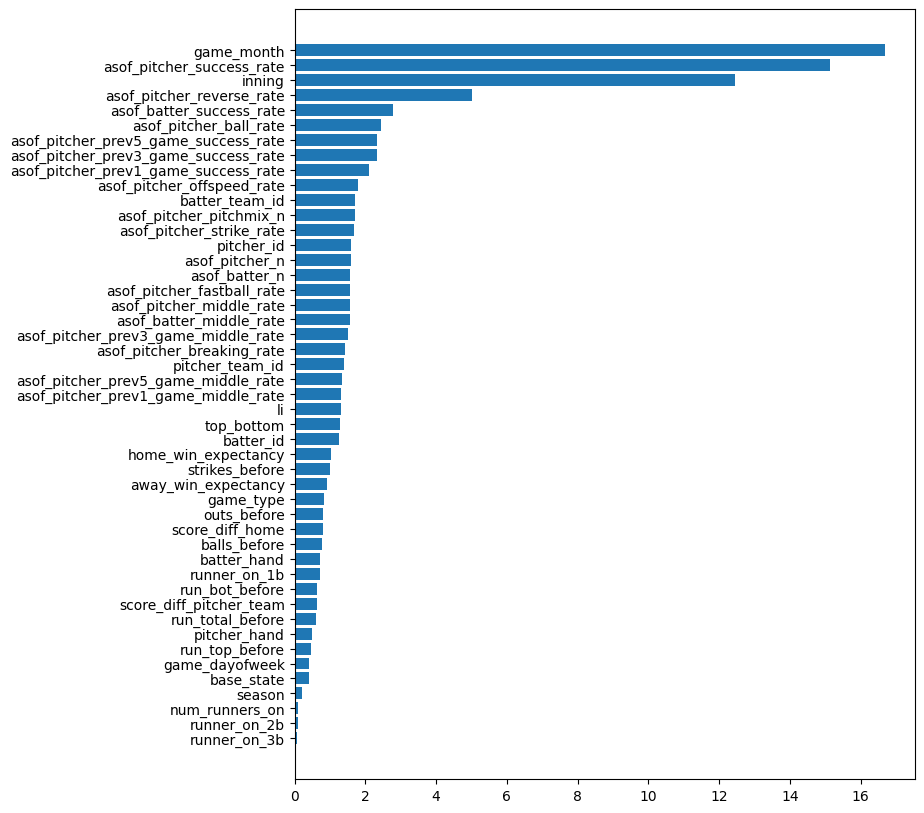

In [23]:
params = {
    'loss_function':"Logloss",
    'eval_metric':"BrierScore",
    'iterations':100,
    'depth':10,
    'learning_rate':0.05,        
    'grow_policy':"Depthwise",
    'min_data_in_leaf':200,
    'random_seed':config.seed,
    'thread_count':-1
}

model = CatBoostClassifier(**params)

t = time.time()
model.fit(X_train_processed,y_train)
spent = time.time() - t
print(f"학습 완료 :: {spent:.1f}s")

val_pred = model.predict_proba(X_val_processed)[:, 1]

score, brier, baseline_brier = brier_skill_score(y_val, val_pred)
importance_df = return_importance_df()

plt.figure(figsize=(8, 10))
plt.barh(importance_df['feature'],importance_df['importance'])

name = "baseline_catboost"
append_results(name)

delete_ids

train: (1221585, 45)
val: (253507, 45)
[LightGBM] [Info] Number of positive: 649372, number of negative: 572213
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029912 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5869
[LightGBM] [Info] Number of data points in the train set: 1221585, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.531582 -> initscore=0.126494
[LightGBM] [Info] Start training from score 0.126494
학습 완료 :: 3.1s
Brier: 0.248293 | 기준선 r(1-r): 0.249807
Validation Score: 606.21


c:\Users\kaich\Desktop\open\aimers\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,name,validation,time,model,parmeters,importance_df
0,baseline,415.57,28.5,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
1,delete_ids,428.36,28.2,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
2,feature_engineering,470.32,30.4,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
3,baseline_lightgbm,608.94,3.7,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
4,baseline_catboost,565.64,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
5,delete_ids_lightgbm,606.21,3.1,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...


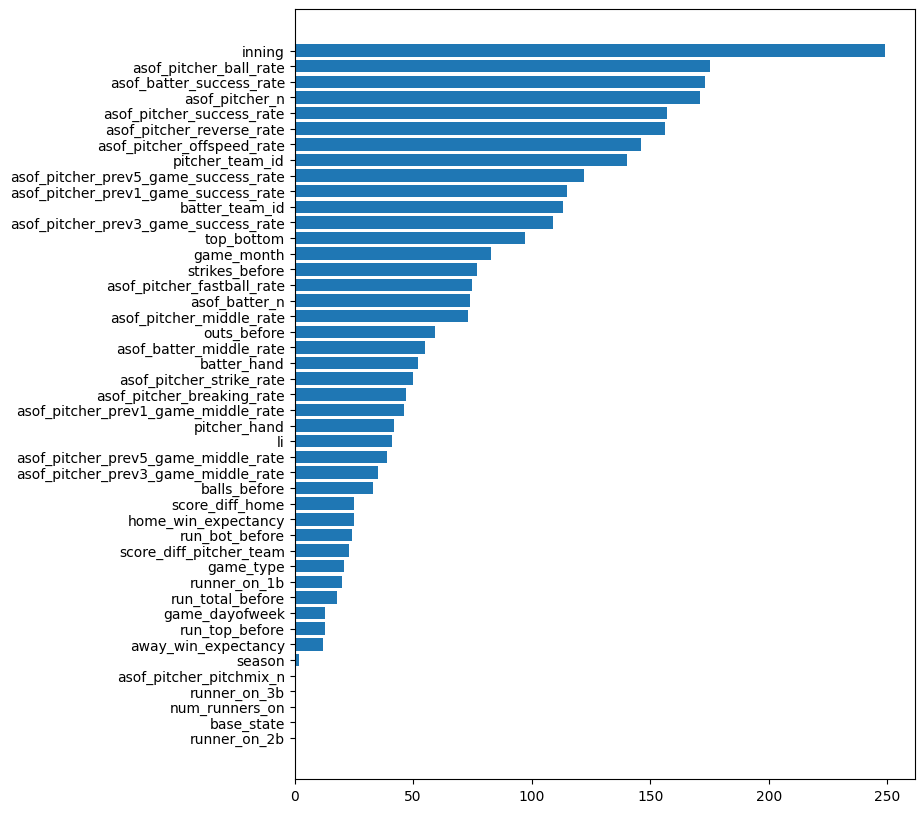

In [24]:
CAT_COLS = ["top_bottom", "game_type", "base_state"]
config = Config(cat_cols = CAT_COLS)
target = config.target
features = [col for col in train.columns if col not in [target] + config.id_cols]
num_cols = [col for col in features if col not in config.cat_cols]

preprocessor = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value",
                           unknown_value=-1), config.cat_cols),
    ("num", SimpleImputer(strategy="median"), num_cols),
])

y_train, y_val = train.loc[:,target], val.loc[:,target]
X_train, X_val = train.loc[:,features], val.loc[:,features]
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print('train:', X_train_processed.shape)
print('val:', X_val_processed.shape)

params = {
    'objective':"binary",
    'n_estimators':100,
    'max_depth':10,
    'min_child_samples':200,
    'learning_rate':0.05,
    'n_jobs':-1,
    'random_state': config.seed
}

model = LGBMClassifier(**params)

t = time.time()
model.fit(X_train_processed,y_train)
spent = time.time() - t
print(f"학습 완료 :: {spent:.1f}s")

val_pred = model.predict_proba(X_val_processed)[:, 1]

score, brier, baseline_brier = brier_skill_score(y_val, val_pred)
importance_df = return_importance_df()

plt.figure(figsize=(8, 10))
plt.barh(importance_df['feature'],importance_df['importance'])

name = "delete_ids_lightgbm"
append_results(name)

0:	learn: 0.2494824	total: 239ms	remaining: 23.6s
1:	learn: 0.2490055	total: 508ms	remaining: 24.9s
2:	learn: 0.2485684	total: 778ms	remaining: 25.1s
3:	learn: 0.2481842	total: 1.02s	remaining: 24.5s
4:	learn: 0.2478366	total: 1.26s	remaining: 24s
5:	learn: 0.2475088	total: 1.51s	remaining: 23.7s
6:	learn: 0.2472344	total: 1.71s	remaining: 22.7s
7:	learn: 0.2469818	total: 1.97s	remaining: 22.7s
8:	learn: 0.2467320	total: 2.23s	remaining: 22.6s
9:	learn: 0.2465058	total: 2.49s	remaining: 22.4s
10:	learn: 0.2462990	total: 2.75s	remaining: 22.3s
11:	learn: 0.2460965	total: 2.99s	remaining: 21.9s
12:	learn: 0.2459262	total: 3.21s	remaining: 21.5s
13:	learn: 0.2457680	total: 3.43s	remaining: 21.1s
14:	learn: 0.2456395	total: 3.65s	remaining: 20.7s
15:	learn: 0.2454962	total: 3.9s	remaining: 20.5s
16:	learn: 0.2453541	total: 4.15s	remaining: 20.3s
17:	learn: 0.2452335	total: 4.39s	remaining: 20s
18:	learn: 0.2451071	total: 4.61s	remaining: 19.7s
19:	learn: 0.2449889	total: 4.86s	remaining: 1

,name,validation,time,model,parmeters,importance_df
0,baseline,415.57,28.5,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
1,delete_ids,428.36,28.2,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
2,feature_engineering,470.32,30.4,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
3,baseline_lightgbm,608.94,3.7,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
4,baseline_catboost,565.64,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
5,delete_ids_lightgbm,606.21,3.1,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
6,delete_ids_catboost,572.76,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...


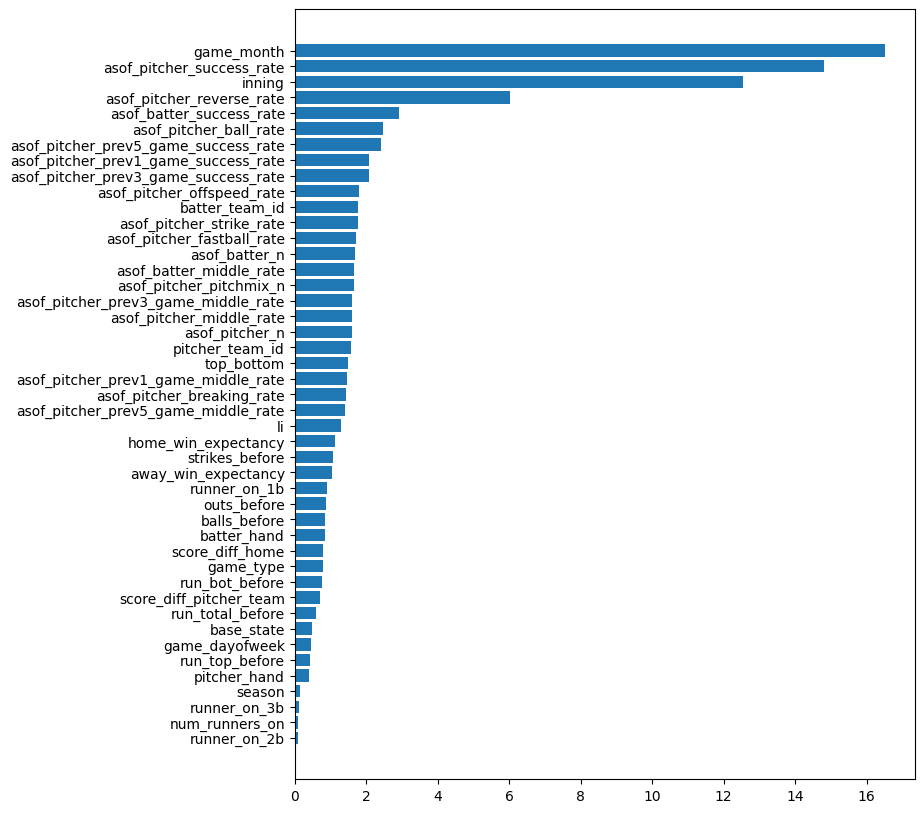

In [25]:
params = {
    'loss_function':"Logloss",
    'eval_metric':"BrierScore",
    'iterations':100,
    'depth':10,
    'learning_rate':0.05,        
    'grow_policy':"Depthwise",
    'min_data_in_leaf':200,
    'random_seed':config.seed,
    'thread_count':-1
}

model = CatBoostClassifier(**params)

t = time.time()
model.fit(X_train_processed,y_train)
spent = time.time() - t
print(f"학습 완료 :: {spent:.1f}s")

val_pred = model.predict_proba(X_val_processed)[:, 1]

score, brier, baseline_brier = brier_skill_score(y_val, val_pred)
importance_df = return_importance_df()

plt.figure(figsize=(8, 10))
plt.barh(importance_df['feature'],importance_df['importance'])

name = "delete_ids_catboost"
append_results(name)

feature_engineering

In [26]:
config = Config()
train,state = preprocess_data(train,config=config,fit=True)
val,_ = preprocess_data(val,config=config,state=state,fit=False)

train: (1221585, 49)
val: (253507, 49)
[LightGBM] [Info] Number of positive: 649372, number of negative: 572213
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027677 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5301
[LightGBM] [Info] Number of data points in the train set: 1221585, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.531582 -> initscore=0.126494
[LightGBM] [Info] Start training from score 0.126494
학습 완료 :: 2.3s
Brier: 0.248076 | 기준선 r(1-r): 0.249807
Validation Score: 692.96


c:\Users\kaich\Desktop\open\aimers\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,name,validation,time,model,parmeters,importance_df
0,baseline,415.57,28.5,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
1,delete_ids,428.36,28.2,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
2,feature_engineering,470.32,30.4,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
3,baseline_lightgbm,608.94,3.7,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
4,baseline_catboost,565.64,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
5,delete_ids_lightgbm,606.21,3.1,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
6,delete_ids_catboost,572.76,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
7,feature_engineering_lightgbm,692.96,2.3,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...


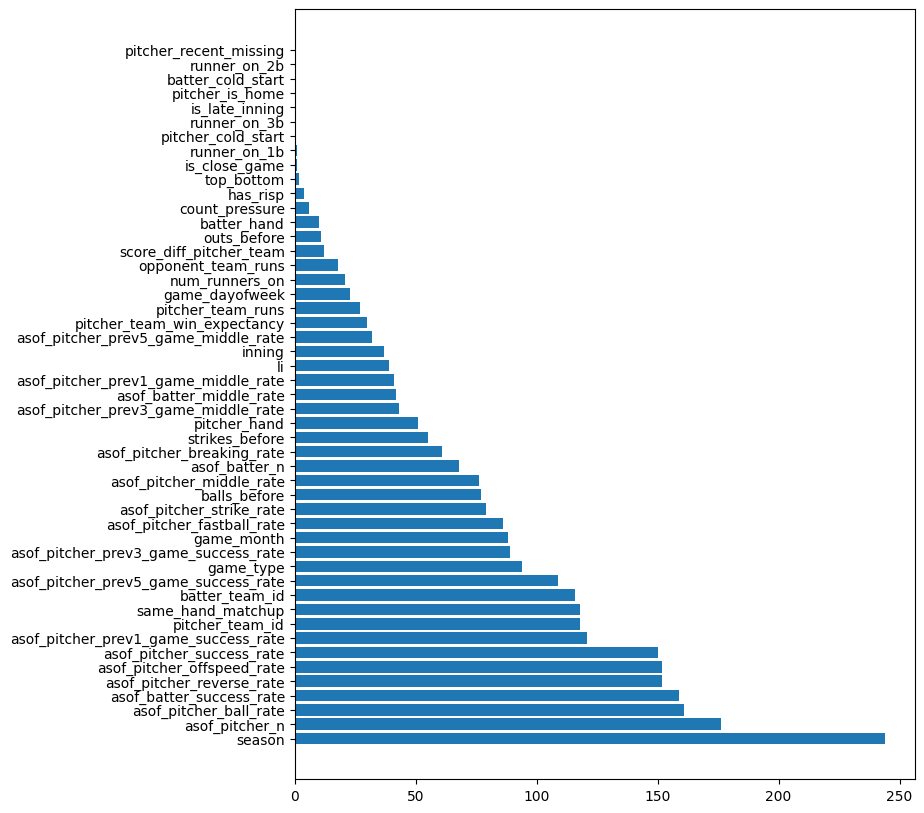

In [58]:
target = config.target
features = [col for col in train.columns if col not in [target] + config.id_cols]
cat_cols = state['categorical_cols']
num_cols = [col for col in features if col not in cat_cols]

preprocessor = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value",
                           unknown_value=-1), cat_cols),
    ("num", SimpleImputer(strategy="median"), num_cols),
])

y_train, y_val = train.loc[:,target], val.loc[:,target]
X_train, X_val = train.loc[:,features], val.loc[:,features]
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print('train:', X_train_processed.shape)
print('val:', X_val_processed.shape)

params = {
    'objective':"binary",
    'n_estimators':100,
    'max_depth':10,
    'min_child_samples':200,
    'learning_rate':0.05,
    'n_jobs':-1,
    'random_state': config.seed
}

model = LGBMClassifier(**params)

t = time.time()
model.fit(X_train_processed,y_train)
spent = time.time() - t
print(f"학습 완료 :: {spent:.1f}s")

val_pred = model.predict_proba(X_val_processed)[:, 1]

score, brier, baseline_brier = brier_skill_score(y_val, val_pred)
importance_df = return_importance_df()

plt.figure(figsize=(8, 10))
plt.barh(importance_df['feature'],importance_df['importance'])

name = "feature_engineering_lightgbm"
append_results(name)

0:	learn: 0.2494833	total: 257ms	remaining: 25.5s
1:	learn: 0.2490207	total: 489ms	remaining: 24s
2:	learn: 0.2485824	total: 760ms	remaining: 24.6s
3:	learn: 0.2481909	total: 1.01s	remaining: 24.3s
4:	learn: 0.2478361	total: 1.25s	remaining: 23.7s
5:	learn: 0.2475121	total: 1.5s	remaining: 23.5s
6:	learn: 0.2472130	total: 1.76s	remaining: 23.4s
7:	learn: 0.2469520	total: 2.02s	remaining: 23.2s
8:	learn: 0.2467065	total: 2.26s	remaining: 22.9s
9:	learn: 0.2464606	total: 2.51s	remaining: 22.6s
10:	learn: 0.2462499	total: 2.75s	remaining: 22.3s
11:	learn: 0.2460503	total: 3.05s	remaining: 22.3s
12:	learn: 0.2458788	total: 3.28s	remaining: 21.9s
13:	learn: 0.2456963	total: 3.54s	remaining: 21.8s
14:	learn: 0.2455476	total: 3.78s	remaining: 21.4s
15:	learn: 0.2454002	total: 4.03s	remaining: 21.2s
16:	learn: 0.2452631	total: 4.28s	remaining: 20.9s
17:	learn: 0.2451436	total: 4.55s	remaining: 20.8s
18:	learn: 0.2450310	total: 4.79s	remaining: 20.4s
19:	learn: 0.2449214	total: 5.04s	remaining:

,name,validation,time,model,parmeters,importance_df
0,baseline,415.57,28.5,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
1,delete_ids,428.36,28.2,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
2,feature_engineering,470.32,30.4,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
3,baseline_lightgbm,608.94,3.7,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
4,baseline_catboost,565.64,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
5,delete_ids_lightgbm,606.21,3.1,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
6,delete_ids_catboost,572.76,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
7,feature_engineering_lightgbm,692.96,2.3,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
8,feature_engineering_catboost,694.27,24.4,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...


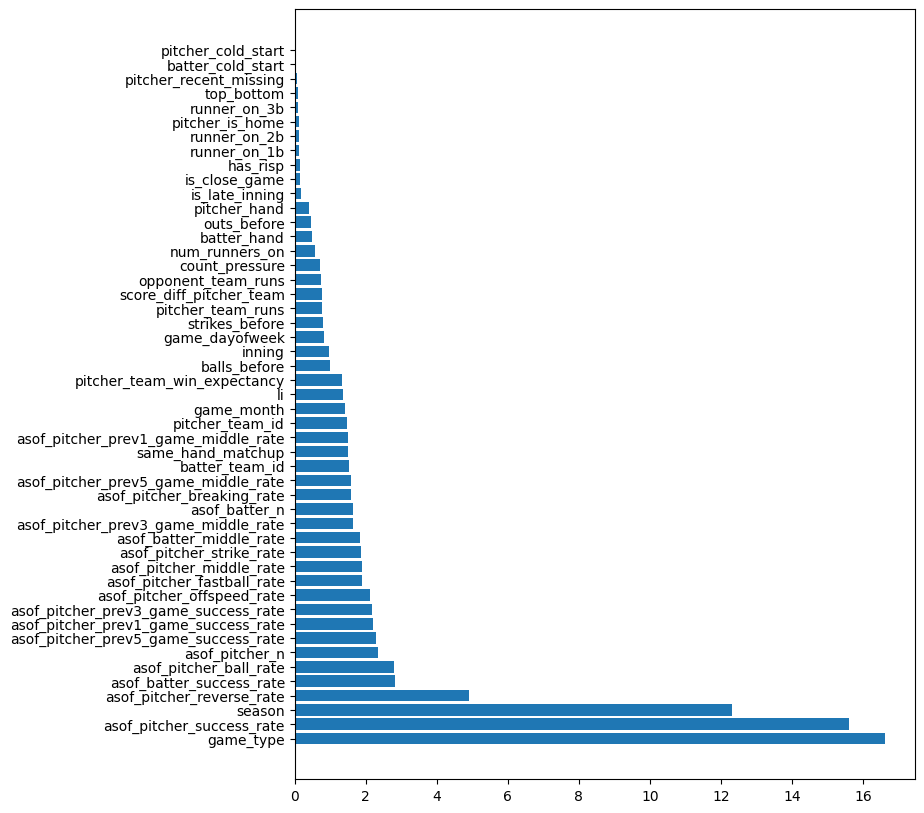

In [59]:
params = {
    'loss_function':"Logloss",
    'eval_metric':"BrierScore",
    'iterations':100,
    'depth':10,
    'learning_rate':0.05,        
    'grow_policy':"Depthwise",
    'min_data_in_leaf':200,
    'random_seed':config.seed,
    'thread_count':-1
}

model = CatBoostClassifier(**params)

t = time.time()
model.fit(X_train_processed,y_train)
spent = time.time() - t
print(f"학습 완료 :: {spent:.1f}s")

val_pred = model.predict_proba(X_val_processed)[:, 1]

score, brier, baseline_brier = brier_skill_score(y_val, val_pred)
importance_df = return_importance_df()

plt.figure(figsize=(8, 10))
plt.barh(importance_df['feature'],importance_df['importance'])

name = "feature_engineering_catboost"
append_results(name)

<Axes: xlabel='validation', ylabel='name'>

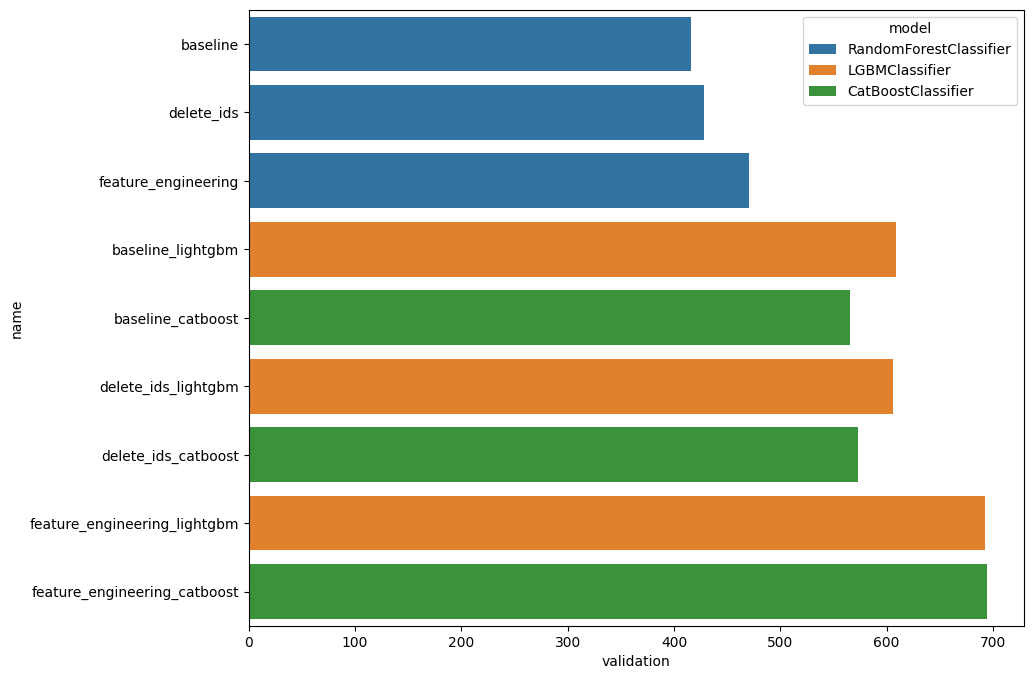

In [60]:
results1 = show_results()

plt.figure(figsize=(10,8))
sns.barplot(data=results1, y='name',x='validation',hue='model')

In [61]:
show_results()

,name,validation,time,model,parmeters,importance_df
0,baseline,415.57,28.5,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
1,delete_ids,428.36,28.2,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
2,feature_engineering,470.32,30.4,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
3,baseline_lightgbm,608.94,3.7,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
4,baseline_catboost,565.64,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
5,delete_ids_lightgbm,606.21,3.1,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
6,delete_ids_catboost,572.76,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
7,feature_engineering_lightgbm,692.96,2.3,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
8,feature_engineering_catboost,694.27,24.4,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...


ensemble

In [62]:
params = {
    'objective':"binary",
    'n_estimators':100,
    'max_depth':10,
    'min_child_samples':200,
    'learning_rate':0.05,
    'n_jobs':-1,
    'random_state': config.seed
}

model = LGBMClassifier(**params)
model.fit(X_train_processed,y_train)
lgbm_pred = model.predict_proba(X_val_processed)[:, 1]

params = {
    'loss_function':"Logloss",
    'eval_metric':"BrierScore",
    'iterations':100,
    'depth':10,
    'learning_rate':0.05,        
    'grow_policy':"Depthwise",
    'min_data_in_leaf':200,
    'random_seed':config.seed,
    'thread_count':-1
}

model = CatBoostClassifier(**params)
model.fit(X_train_processed,y_train)
cat_pred = model.predict_proba(X_val_processed)[:, 1]

val_pred = (0.5 * lgbm_pred + 0.5 * cat_pred)
score, brier, baseline_brier = brier_skill_score(y_val, val_pred)
importance_df = 0

name = "feature_engineering_ensemble"
append_results(name)

[LightGBM] [Info] Number of positive: 649372, number of negative: 572213
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033032 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5301
[LightGBM] [Info] Number of data points in the train set: 1221585, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.531582 -> initscore=0.126494
[LightGBM] [Info] Start training from score 0.126494


c:\Users\kaich\Desktop\open\aimers\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0:	learn: 0.2494833	total: 239ms	remaining: 23.6s
1:	learn: 0.2490207	total: 475ms	remaining: 23.3s
2:	learn: 0.2485824	total: 718ms	remaining: 23.2s
3:	learn: 0.2481909	total: 968ms	remaining: 23.2s
4:	learn: 0.2478361	total: 1.21s	remaining: 23s
5:	learn: 0.2475121	total: 1.47s	remaining: 23s
6:	learn: 0.2472130	total: 1.71s	remaining: 22.8s
7:	learn: 0.2469520	total: 1.97s	remaining: 22.7s
8:	learn: 0.2467065	total: 2.2s	remaining: 22.2s
9:	learn: 0.2464606	total: 2.45s	remaining: 22.1s
10:	learn: 0.2462499	total: 2.69s	remaining: 21.8s
11:	learn: 0.2460503	total: 2.95s	remaining: 21.6s
12:	learn: 0.2458788	total: 3.18s	remaining: 21.3s
13:	learn: 0.2456963	total: 3.44s	remaining: 21.1s
14:	learn: 0.2455476	total: 3.66s	remaining: 20.7s
15:	learn: 0.2454002	total: 3.89s	remaining: 20.4s
16:	learn: 0.2452631	total: 4.12s	remaining: 20.1s
17:	learn: 0.2451436	total: 4.39s	remaining: 20s
18:	learn: 0.2450310	total: 4.62s	remaining: 19.7s
19:	learn: 0.2449214	total: 4.85s	remaining: 19.

,name,validation,time,model,parmeters,importance_df
0,baseline,415.57,28.5,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
1,delete_ids,428.36,28.2,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
2,feature_engineering,470.32,30.4,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
3,baseline_lightgbm,608.94,3.7,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
4,baseline_catboost,565.64,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
5,delete_ids_lightgbm,606.21,3.1,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
6,delete_ids_catboost,572.76,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
7,feature_engineering_lightgbm,692.96,2.3,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
8,feature_engineering_catboost,694.27,24.4,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
9,feature_engineering_ensemble,719.14,24.4,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",0


native categorical

In [75]:
def return_importance_df():
    return pd.DataFrame({'feature': X_train.columns,
                         'importance': model.feature_importances_
                         }).sort_values('importance')

In [6]:
def preprocess_data_cat(df, config=None,state=None,fit=False):
    processed_df = df.copy()
    config = config

    categorical_cols = config.cat_cols

    is_top = processed_df["top_bottom"].eq("T")
    processed_df["pitcher_is_home"] = is_top.astype("int8")
    processed_df["pitcher_team_runs"] = np.where(is_top, processed_df["run_bot_before"], processed_df["run_top_before"]).astype("int16")
    processed_df["opponent_team_runs"] = np.where(is_top, processed_df["run_top_before"], processed_df["run_bot_before"]).astype("int16")
    processed_df["pitcher_team_win_expectancy"] = np.where(is_top, processed_df["home_win_expectancy"], processed_df["away_win_expectancy"])
    processed_df["pitcher_cold_start"] = (processed_df["asof_pitcher_n"].eq(0) | processed_df["asof_pitcher_success_rate"].isna()).astype("int8")
    processed_df["batter_cold_start"] = (processed_df["asof_batter_n"].eq(0) | processed_df["asof_batter_success_rate"].isna()).astype("int8")

    recent_cols = config.recent_cols

    processed_df["pitcher_recent_missing"] = (processed_df[recent_cols].isna().any(axis=1).astype("int8"))

    processed_df["is_late_inning"] = (processed_df["inning"].ge(7).astype("int8"))
    processed_df["is_close_game"] = (processed_df["score_diff_pitcher_team"].abs().le(1).astype("int8"))
    processed_df["has_risp"] = (processed_df["runner_on_2b"].eq(1) | processed_df["runner_on_3b"].eq(1)).astype("int8")
    processed_df["count_pressure"] = (processed_df["balls_before"]+ processed_df["strikes_before"]).astype("int8")
    processed_df["same_hand_matchup"] = (processed_df["pitcher_hand"] == processed_df["batter_hand"]).astype("int8")

    drop_cols = config.drop_cols

    if fit:
        state = {
            "categories": {},
            "drop_cols": [],
        }

        state["drop_cols"].extend(drop_cols)

    elif state is None:
        raise ValueError("validation/test 변환 시 train에서 생성한 state를 전달해야 합니다.")

    processed_df = processed_df.drop(
        columns=state["drop_cols"],
        errors="ignore",
    )

    existing_cat_cols = [col for col in categorical_cols if col in processed_df.columns]

    for col in existing_cat_cols:
        values = processed_df[col].astype("string").fillna('__MISSING__')
        processed_df[col] = values.astype(str)

    state["categorical_cols"] = existing_cat_cols

    return processed_df, state

In [65]:
full_train = pd.read_csv(os.path.join(Config().data_dir, 'train.csv'))
train = full_train.loc[full_train.season < 2024].copy()
val = full_train.loc[full_train.season == 2024].copy()

print("full_train",full_train.shape)
print("train",train.shape)
print("validation",val.shape)

config = Config()
train,state = preprocess_data(train,config=config,fit=True)
val,_ = preprocess_data(val,config=config,state=state,fit=False)

full_train (1475092, 49)
train (1221585, 49)
validation (253507, 49)


In [73]:
target = config.target
features = [col for col in train.columns if col not in [target] + config.id_cols]
cat_cols = state['categorical_cols']
num_cols = [col for col in features if col not in cat_cols]

y_train, y_val = train.loc[:,target], val.loc[:,target]
X_train, X_val = train.loc[:,features], val.loc[:,features]

print('train:', X_train.shape)
print('val:', X_val.shape)

train: (1221585, 49)
val: (253507, 49)


[LightGBM] [Info] Number of positive: 649372, number of negative: 572213
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031602 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5306
[LightGBM] [Info] Number of data points in the train set: 1221585, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.531582 -> initscore=0.126494
[LightGBM] [Info] Start training from score 0.126494
학습 완료 :: 3.2s
Brier: 0.248081 | 기준선 r(1-r): 0.249807
Validation Score: 690.78


,name,validation,time,model,parmeters,importance_df
0,baseline,415.57,28.5,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
1,delete_ids,428.36,28.2,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
2,feature_engineering,470.32,30.4,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
3,baseline_lightgbm,608.94,3.7,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
4,baseline_catboost,565.64,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
5,delete_ids_lightgbm,606.21,3.1,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
6,delete_ids_catboost,572.76,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
7,feature_engineering_lightgbm,692.96,2.3,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
8,feature_engineering_catboost,694.27,24.4,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
9,feature_engineering_ensemble,719.14,24.4,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",0


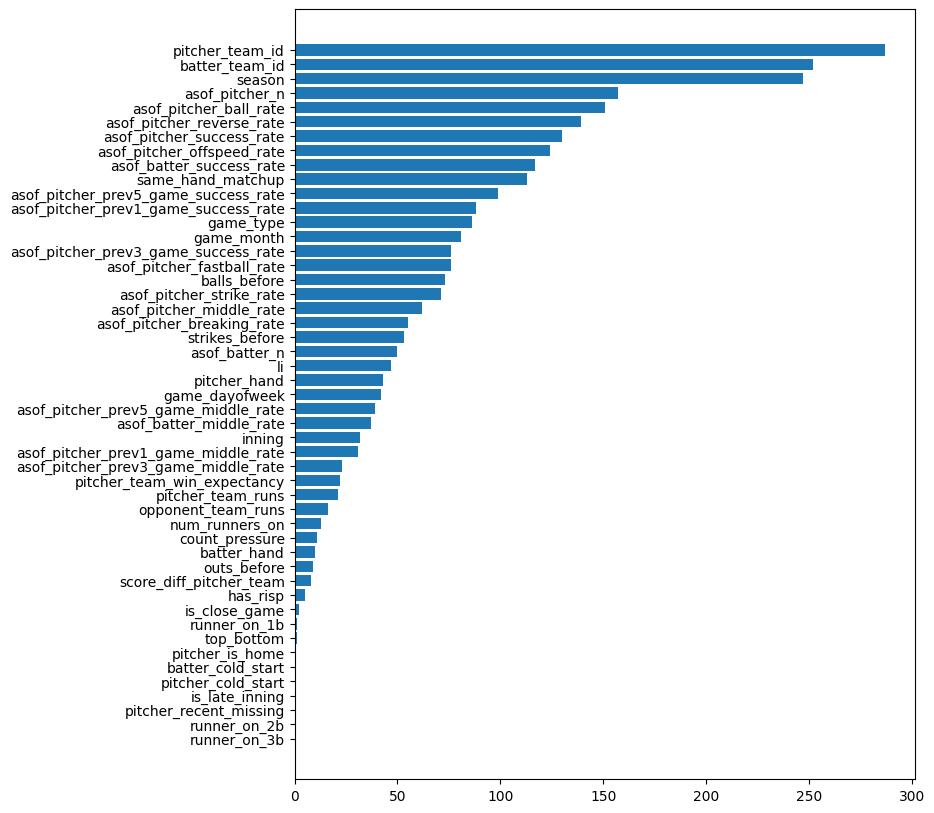

In [76]:
params = {
    'objective':"binary",
    'n_estimators':100,
    'max_depth':10,
    'min_child_samples':200,
    'learning_rate':0.05,
    'n_jobs':-1,
    'random_state': config.seed
}

model = LGBMClassifier(**params)

t = time.time()
model.fit(X_train,y_train,categorical_feature=cat_cols)
spent = time.time() - t
print(f"학습 완료 :: {spent:.1f}s")

val_pred = model.predict_proba(X_val)[:, 1]

score, brier, baseline_brier = brier_skill_score(y_val, val_pred)
importance_df = return_importance_df()

plt.figure(figsize=(8, 10))
plt.barh(importance_df['feature'],importance_df['importance'])

name = "native_categorical_lightgbm"
append_results(name)

In [80]:
full_train = pd.read_csv(os.path.join(Config().data_dir, 'train.csv'))
train = full_train.loc[full_train.season < 2024].copy()
val = full_train.loc[full_train.season == 2024].copy()

print("full_train",full_train.shape)
print("train",train.shape)
print("validation",val.shape)

train_cb,state_cb = preprocess_data_cat(train,config=config,fit=True)
val_cb,_ = preprocess_data_cat(val,config=config,state=state_cb,fit=False)

target = config.target
features = [col for col in train_cb.columns if col not in [target] + config.id_cols]
cat_cols = state_cb['categorical_cols']
num_cols = [col for col in features if col not in cat_cols]

y_train, y_val = train_cb.loc[:,target], val_cb.loc[:,target]
X_train, X_val = train_cb.loc[:,features], val_cb.loc[:,features]

print('train:', X_train.shape)
print('val:', X_val.shape)

full_train (1475092, 49)
train (1221585, 49)
validation (253507, 49)
train: (1221585, 49)
val: (253507, 49)


0:	learn: 0.2494934	total: 746ms	remaining: 1m 13s
1:	learn: 0.2490174	total: 1.47s	remaining: 1m 11s
2:	learn: 0.2485907	total: 2.2s	remaining: 1m 11s
3:	learn: 0.2482204	total: 2.9s	remaining: 1m 9s
4:	learn: 0.2478752	total: 3.64s	remaining: 1m 9s
5:	learn: 0.2475463	total: 4.38s	remaining: 1m 8s
6:	learn: 0.2472476	total: 5.09s	remaining: 1m 7s
7:	learn: 0.2469636	total: 5.8s	remaining: 1m 6s
8:	learn: 0.2467272	total: 6.47s	remaining: 1m 5s
9:	learn: 0.2464869	total: 7.16s	remaining: 1m 4s
10:	learn: 0.2462670	total: 7.82s	remaining: 1m 3s
11:	learn: 0.2460682	total: 8.45s	remaining: 1m 1s
12:	learn: 0.2458840	total: 9.12s	remaining: 1m 1s
13:	learn: 0.2457291	total: 9.72s	remaining: 59.7s
14:	learn: 0.2455849	total: 10.4s	remaining: 58.8s
15:	learn: 0.2454283	total: 11.1s	remaining: 58.2s
16:	learn: 0.2452959	total: 11.7s	remaining: 57.2s
17:	learn: 0.2451886	total: 12.3s	remaining: 56.2s
18:	learn: 0.2450686	total: 12.9s	remaining: 55.1s
19:	learn: 0.2449624	total: 13.6s	remaini

,name,validation,time,model,parmeters,importance_df
0,baseline,415.57,28.5,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
1,delete_ids,428.36,28.2,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
2,feature_engineering,470.32,30.4,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
3,baseline_lightgbm,608.94,3.7,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
4,baseline_catboost,565.64,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
5,delete_ids_lightgbm,606.21,3.1,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
6,delete_ids_catboost,572.76,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
7,feature_engineering_lightgbm,692.96,2.3,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
8,feature_engineering_catboost,694.27,24.4,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
9,feature_engineering_ensemble,719.14,24.4,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",0


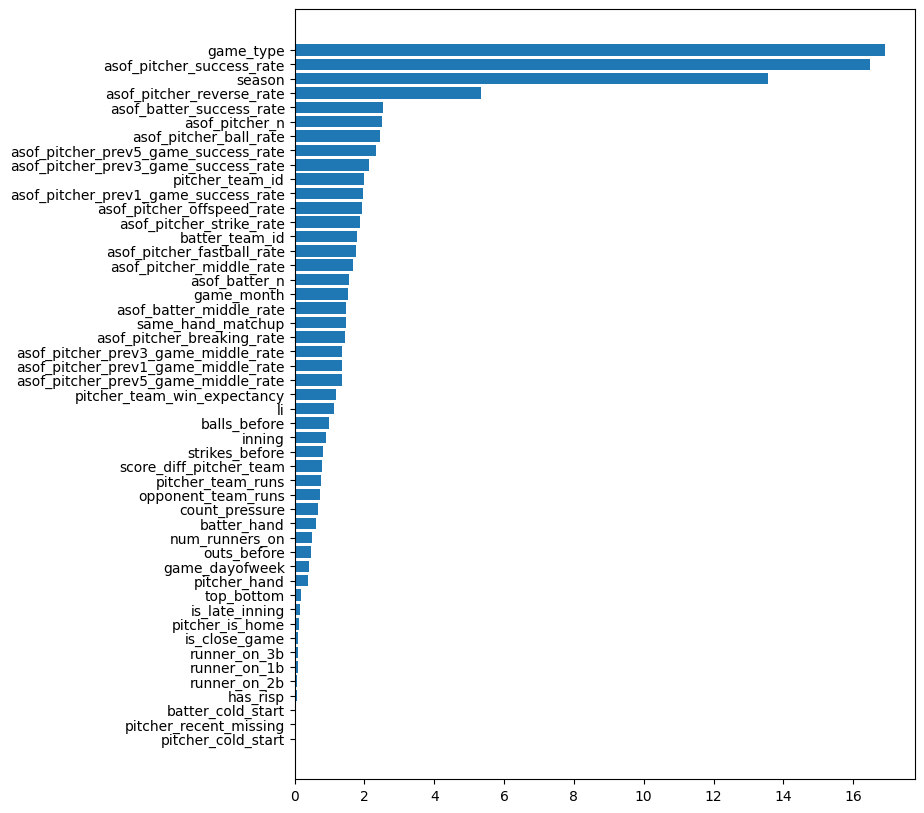

In [81]:
params = {
    'loss_function':"Logloss",
    'eval_metric':"BrierScore",
    'iterations':100,
    'depth':10,
    'learning_rate':0.05,        
    'grow_policy':"Depthwise",
    'min_data_in_leaf':200,
    'random_seed':config.seed,
    'thread_count':-1
}

model = CatBoostClassifier(**params)

t = time.time()
model.fit(X_train,y_train,cat_features=cat_cols)
spent = time.time() - t
print(f"학습 완료 :: {spent:.1f}s")

val_pred = model.predict_proba(X_val)[:, 1]

score, brier, baseline_brier = brier_skill_score(y_val, val_pred)
importance_df = return_importance_df()

plt.figure(figsize=(8, 10))
plt.barh(importance_df['feature'],importance_df['importance'])

name = "native_categorical_catboost"
append_results(name)

In [83]:
val_pred = (0.5 * lgbm_pred + 0.5 * val_pred)
score, brier, baseline_brier = brier_skill_score(y_val, val_pred)
importance_df = 0

name = "best_ensemble"
append_results(name)

Brier: 0.247980 | 기준선 r(1-r): 0.249807
Validation Score: 731.45


,name,validation,time,model,parmeters,importance_df
0,baseline,415.57,28.5,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
1,delete_ids,428.36,28.2,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
2,feature_engineering,470.32,30.4,RandomForestClassifier,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",feature impo...
3,baseline_lightgbm,608.94,3.7,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
4,baseline_catboost,565.64,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
5,delete_ids_lightgbm,606.21,3.1,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
6,delete_ids_catboost,572.76,23.2,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
7,feature_engineering_lightgbm,692.96,2.3,LGBMClassifier,"{'objective': 'binary', 'n_estimators': 100, '...",feature impo...
8,feature_engineering_catboost,694.27,24.4,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",feature impo...
9,feature_engineering_ensemble,719.14,24.4,CatBoostClassifier,"{'loss_function': 'Logloss', 'eval_metric': 'B...",0


<Axes: xlabel='validation', ylabel='name'>

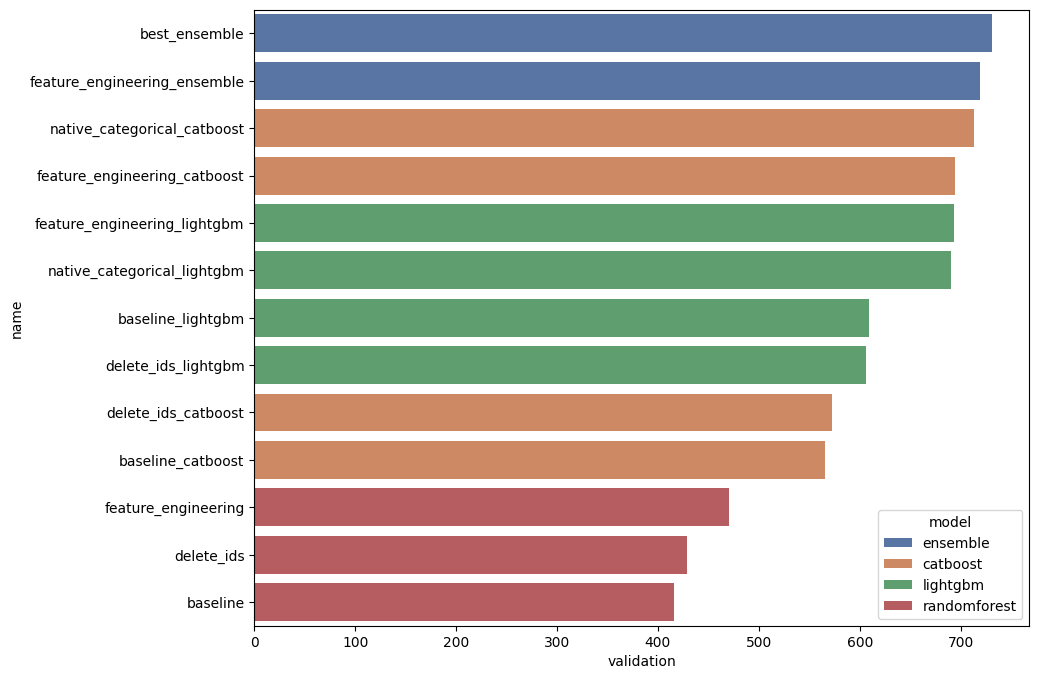

In [115]:
result2 = show_results()
types = ['lightgbm','catboost','ensemble']

for i in range(len(result2)):
    name = result2.loc[i,'name']
    splits = name.split('_')
    is_types = splits[-1] in types
    model_name = splits[-1] if is_types else 'randomforest'
    how = '_'.join(splits[:-1]) if is_types else '_'.join(splits)

    result2.loc[i,'model'] = model_name
    result2.loc[i,'experiment'] = how

result2.sort_values(by='validation',ascending=False,inplace=True)
plt.figure(figsize=(10,8))
sns.barplot(data=result2,y='name',x='validation',hue='model', palette='deep')

중간제출

In [13]:
import joblib
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [15]:
full_train = pd.read_csv(os.path.join(Config().data_dir, 'train.csv'))
print("full_train",full_train.shape)

full_train (1475092, 49)


In [16]:
config = Config()
train_cb,state_cb = preprocess_data_cat(full_train,config=config,fit=True)

target = config.target
features = [col for col in train_cb.columns if col not in [target] + config.id_cols]
cat_cols = state_cb['categorical_cols']
num_cols = [col for col in features if col not in cat_cols]

X_train, y_train = train_cb.loc[:,features], train_cb.loc[:,target]

print('train:', X_train.shape)

params = {
    'loss_function':"Logloss",
    'eval_metric':"BrierScore",
    'iterations':100,
    'depth':10,
    'learning_rate':0.05,        
    'grow_policy':"Depthwise",
    'min_data_in_leaf':200,
    'random_seed':config.seed,
    'thread_count':-1
}

model = CatBoostClassifier(**params)
model.fit(X_train,y_train,cat_features=cat_cols)

os.makedirs("./model", exist_ok=True)
catboost_bundle = {
    'model':model,
    'state':state_cb,
    'features':features
}
joblib.dump(catboost_bundle, "./model/cb_bundle.pkl", compress=3)
print("저장 완료: ./model/cb_bundle.pkl")

train: (1475092, 49)
0:	learn: 0.2495451	total: 876ms	remaining: 1m 26s
1:	learn: 0.2491569	total: 1.62s	remaining: 1m 19s
2:	learn: 0.2487770	total: 2.38s	remaining: 1m 16s
3:	learn: 0.2484315	total: 3.12s	remaining: 1m 14s
4:	learn: 0.2481283	total: 3.92s	remaining: 1m 14s
5:	learn: 0.2478529	total: 4.67s	remaining: 1m 13s
6:	learn: 0.2475775	total: 5.42s	remaining: 1m 12s
7:	learn: 0.2473399	total: 6.18s	remaining: 1m 11s
8:	learn: 0.2471157	total: 6.91s	remaining: 1m 9s
9:	learn: 0.2469195	total: 7.63s	remaining: 1m 8s
10:	learn: 0.2467430	total: 8.39s	remaining: 1m 7s
11:	learn: 0.2465696	total: 9.16s	remaining: 1m 7s
12:	learn: 0.2464057	total: 9.95s	remaining: 1m 6s
13:	learn: 0.2462541	total: 10.7s	remaining: 1m 5s
14:	learn: 0.2461235	total: 11.3s	remaining: 1m 4s
15:	learn: 0.2460032	total: 12s	remaining: 1m 3s
16:	learn: 0.2458753	total: 12.8s	remaining: 1m 2s
17:	learn: 0.2457693	total: 13.5s	remaining: 1m 1s
18:	learn: 0.2456740	total: 14.3s	remaining: 1m 1s
19:	learn: 0.2

In [17]:
train,state = preprocess_data(full_train,config=config,fit=True)

target = config.target
features = [col for col in train.columns if col not in [target] + config.id_cols]
cat_cols = state['categorical_cols']
num_cols = [col for col in features if col not in cat_cols]

preprocessor = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value",
                           unknown_value=-1), cat_cols),
    ("num", SimpleImputer(strategy="median"), num_cols),
])

X_train, y_train = train.loc[:,features], train.loc[:,target]
X_train_processed = preprocessor.fit_transform(X_train)

print('train:', X_train_processed.shape)

params = {
    'objective':"binary",
    'n_estimators':100,
    'max_depth':10,
    'min_child_samples':200,
    'learning_rate':0.05,
    'n_jobs':-1,
    'random_state': config.seed
}

model = LGBMClassifier(**params)
model.fit(X_train_processed,y_train)

os.makedirs("./model", exist_ok=True)
lightgbm_bundle = {
    "model": model,
    "state": state,
    "preprocessor": preprocessor,
    "features": features
}
joblib.dump(lightgbm_bundle, "./model/lgbm_bundle.pkl", compress=3)
print("저장 완료: ./model/lgbm_bundle.pkl")

train: (1475092, 49)
[LightGBM] [Info] Number of positive: 772603, number of negative: 702489
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040575 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5307
[LightGBM] [Info] Number of data points in the train set: 1475092, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.523766 -> initscore=0.095136
[LightGBM] [Info] Start training from score 0.095136
저장 완료: ./model/lgbm_bundle.pkl


추론

In [ ]:
config = Config()

CATBOOST_MODEL = './model/cb_bundle.pkl'
LIGHTGBM_MODEL = './model/lgbm_bundle.pkl'

OUTPUT_PATH = './output/submission.csv'

In [ ]:
catboost_bundle = joblib.load(CATBOOST_MODEL)
lightgbm_bundle = joblib.load(LIGHTGBM_MODEL)

catboost_model = catboost_bundle["model"]
lightgbm_model = lightgbm_bundle["model"]

test = pd.read_csv(os.path.join(config.data_dir,'test.csv'),encoding="utf-8-sig")
sample_submission = pd.read_csv(os.path.join(config.data_dir,'sample_submission.csv'),encoding="utf-8-sig")

In [131]:
test_cb, _ = preprocess_data_cat(
    test,
    config=config,
    state=catboost_bundle["state"],
    fit=False,
)

cb_features = catboost_bundle["features"]

#------------
missing_cb_features = [
    col for col in cb_features
    if col not in test_cb.columns
]

if missing_cb_features:
    raise ValueError(
        f"CatBoost 테스트 데이터에 없는 피처: "
        f"{missing_cb_features}"
    )
#-------------------
X_test_cb = test_cb.loc[:, cb_features]
cb_pred = catboost_model.predict_proba(X_test_cb)[:, 1]

In [132]:
test_lgbm, _ = preprocess_data(
    test,
    config=config,
    state=lightgbm_bundle["state"],
    fit=False,
)

lgbm_features = lightgbm_bundle["features"]
lgbm_preprocessor = lightgbm_bundle["preprocessor"]

#------------
missing_lgbm_features = [
    col for col in lgbm_features
    if col not in test_lgbm.columns
]

if missing_lgbm_features:
    raise ValueError(
        f"LightGBM 테스트 데이터에 없는 피처: "
        f"{missing_lgbm_features}"
    )
#------------

X_test_lgbm = test_lgbm.loc[:, lgbm_features]
X_test_lgbm_processed = lgbm_preprocessor.transform(X_test_lgbm)

lgbm_pred = lightgbm_model.predict_proba(X_test_lgbm_processed)[:, 1]

c:\Users\kaich\Desktop\open\aimers\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
ensemble_pred = (0.5 * cb_pred+ 0.5 * lgbm_pred)
ensemble_pred = np.clip(ensemble_pred,0.0,1.0)

In [ ]:
ID = config.id
TARGET = config.target

prediction_df = pd.DataFrame({
    ID: test[ID],
    TARGET: ensemble_pred
})

submission = (sample_submission[[ID]].merge(prediction_df,on=ID,how='left',validate='one_to_one'))

#------------
if submission[TARGET].isna().any():
    missing_count = submission[TARGET].isna().sum()

    raise ValueError(
        f"예측값이 없는 row_id가 {missing_count}개 있습니다."
    )
#------------

In [137]:
os.makedirs(os.path.dirname(OUTPUT_PATH),exist_ok=True)
submission.to_csv(OUTPUT_PATH,index=False,encoding='utf-8')